# 记忆库实验

实验基于 `core/` 代码库。每个实验运行前需启动 ollama（已配置）。

结果会缓存到 `experiment_results/` 目录，避免重复运行。

In [1]:
import json
import os
import re
import subprocess
import sys
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

CORE_DIR = Path('.').resolve()
RESULT_DIR = Path('experiment_results').resolve()
RESULT_DIR.mkdir(exist_ok=True)

if str(CORE_DIR) not in sys.path:
    sys.path.insert(0, str(CORE_DIR))

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print(f'Core dir: {CORE_DIR}')
print(f'Results dir: {RESULT_DIR}')

Core dir: /mnt/f/core
Results dir: /mnt/f/core/experiment_results


## 辅助函数

In [2]:
def run_test(strategies: str, test_file: str, test_id: str = '',
             env: dict | None = None, tag: str = '') -> dict:
    """运行单次测试，返回结果摘要。结果缓存在 experiment_results/。"""
    safe_tag = tag or f'{strategies}_{test_file}_{test_id or "all"}'
    cache_path = RESULT_DIR / f'{safe_tag}.json'

    if cache_path.exists():
        print(f'[缓存] 加载 {cache_path.name}')
        return json.loads(cache_path.read_text(encoding='utf-8'))

    cmd = [
        sys.executable, 'main.py',
        '--test-file', test_file,
        '--strategies', strategies,
        '--no-save',
    ]
    if test_id:
        cmd += ['--test-id', test_id]

    proc_env = os.environ.copy()
    proc_env['MEMORY_STRATEGIES'] = strategies
    root_dir = str(Path('.').resolve())
    old_pythonpath = proc_env.get('PYTHONPATH', '')
    proc_env['PYTHONPATH'] = f"{root_dir}{os.pathsep}{old_pythonpath}" if old_pythonpath else root_dir
    if env:
        proc_env.update(env)

    print(f'[运行] {safe_tag}')
    t0 = time.time()
    result = subprocess.run(cmd, cwd=str(CORE_DIR), env=proc_env,
                            capture_output=True, text=True, timeout=3600)
    elapsed = time.time() - t0
    if result.returncode != 0:
        print(f'[错误] {safe_tag} | RC={result.returncode} | {elapsed:.1f}s')
        if result.stderr:
            print(result.stderr[:1500])
        return {
            'tag': tag, 'strategies': strategies, 'test_file': test_file,
            'test_id': test_id, 'env': env or {}, 'elapsed': elapsed,
            'records': [], 'total_passed': 0, 'total_evals': 0,
            'overall_score': 0.0, 'error': True,
            'returncode': result.returncode, 'stderr': result.stderr,
            'stdout': result.stdout,
        }

    print(f'[完成] {safe_tag} | RC=0 | {elapsed:.1f}s')

    # 解析日志: 2024-... | INFO | [id] type | passed/total | score=...
    records = []
    score_re = re.compile(r'\[(.+?)\]\s+(?:consistency|forgetting)\s*\|\s*(\d+)/(\d+)\s*\|\s*score=([\d.]+)')
    for line in result.stdout.split('\n'):
        m = score_re.search(line)
        if m:
            records.append({
                'test_id': m.group(1),
                'passed': int(m.group(2)),
                'total': int(m.group(3)),
                'score': float(m.group(4)),
            })

    total_p = sum(r['passed'] for r in records)
    total_t = sum(r['total'] for r in records)
    summary = {
        'tag': tag,
        'strategies': strategies,
        'test_file': test_file,
        'test_id': test_id,
        'env': env or {},
        'elapsed': elapsed,
        'records': records,
        'total_passed': total_p,
        'total_evals': total_t,
        'overall_score': total_p / total_t if total_t else 0.0,
        'stdout': result.stdout,
        'stderr': result.stderr,
    }
    cache_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')
    return summary


def run_batch(configs: list[dict]) -> list[dict]:
    """并行运行多个测试配置，返回与 configs 同序的结果列表。"""
    if len(configs) <= 1:
        cfg = configs[0].copy() if configs else {}
        tag = cfg.pop('tag', '')
        return [run_test(tag=tag, **cfg)] if cfg else []

    results: dict[int, dict] = {}
    with ThreadPoolExecutor(max_workers=min(len(configs), 4)) as pool:
        futures: dict = {}
        for i, cfg in enumerate(configs):
            cfg_copy = cfg.copy()
            tag = cfg_copy.pop('tag', '')
            futures[pool.submit(run_test, tag=tag, **cfg_copy)] = i

        for fut in as_completed(futures):
            idx = futures[fut]
            try:
                results[idx] = fut.result()
            except Exception as e:
                print(f'[错误] 配置 #{idx} 运行失败: {e}')
                results[idx] = {}

    return [results[i] for i in range(len(configs))]


def extract_score(summary: dict) -> float:
    return summary.get('overall_score', 0.0)


def extract_passed_total(summary: dict) -> tuple[int, int]:
    return summary.get('total_passed', 0), summary.get('total_evals', 0)

---
## 实验 1：上下文窗口大小 vs 一致性

使用 ShortMem 策略，改变 `SECOND_WATER_LEVEL`（滑动窗口触发水位），
测试 `consistency_test_7`，观察上下文窗口大小对一致性的影响。

- `SECOND_WATER_LEVEL` = 触发水位（占 MAX_CONTEXT_WINDOW=18000 的比例）
- 值越大 → 上下文窗口越大 → 保留的历史越多

In [3]:
WINDOW_SIZES = [500, 1000, 1500, 2000, 2500, 3000]

# SECOND_WATER_LEVEL = context_window / MAX_CONTEXT_WINDOW
# MAX_CONTEXT_WINDOW defaults to 8000 in constant.py
# So window=500 → WL=500/8000=0.0625, window=3000 → WL=3000/8000=0.375
exp1_configs = [
    {
        'tag': f'exp1_w{w}',
        'strategies': 'ShortMem',
        'test_file': 'conversation_tests_consistency.json',
        'test_id': 'consistency_test_7',
        'env': {'SHORT_MEM_SECOND_WATER_LEVEL': str(w / 8000)},
    }
    for w in WINDOW_SIZES
]

exp1_summaries = run_batch(exp1_configs)
exp1_results = []
for w, summary in zip(WINDOW_SIZES, exp1_summaries):
    p, t = extract_passed_total(summary)
    exp1_results.append({
        'window': w,
        'score': extract_score(summary),
        'passed': p,
        'total': t,
    })


[缓存] 加载 exp1_w500.json
[缓存] 加载 exp1_w1000.json
[缓存] 加载 exp1_w2000.json
[缓存] 加载 exp1_w1500.json
[缓存] 加载 exp1_w2500.json
[缓存] 加载 exp1_w3000.json


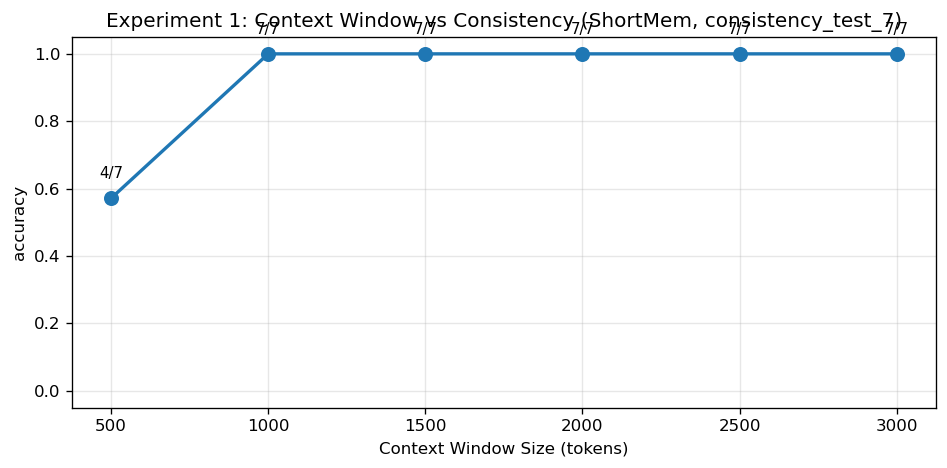

  window=  500  score=0.5714  (4/7)
  window= 1000  score=1.0000  (7/7)
  window= 1500  score=1.0000  (7/7)
  window= 2000  score=1.0000  (7/7)
  window= 2500  score=1.0000  (7/7)
  window= 3000  score=1.0000  (7/7)


In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
xs = [r['window'] for r in exp1_results]
ys = [r['score'] for r in exp1_results]
labels = [f'{r["passed"]}/{r["total"]}' for r in exp1_results]

ax.plot(xs, ys, 'o-', linewidth=2, markersize=8)
for x, y, label in zip(xs, ys, labels):
    ax.annotate(label, (x, y), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=9)
ax.set_xlabel('Context Window Size (tokens)')
ax.set_ylabel('accuracy')
ax.set_title('Experiment 1: Context Window vs Consistency (ShortMem, consistency_test_7)')
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULT_DIR / 'exp1_context_window_vs_consistency.png', dpi=150)
plt.show()
print('\n'.join([
    f'  window={r["window"]:5d}  score={r["score"]:.4f}  ({r["passed"]}/{r["total"]})'
    for r in exp1_results
]))


---
## 实验 2：LongMem vs ShortMem — 遗忘测试

固定上下文窗口（`SECOND_WATER_LEVEL=0.5`），对比 LongMem 和 ShortMem
在 `conversation_tests_forgetting.json` 上的表现。

LongMem 使用 HNSW + BGE-M3 后端。

In [5]:
exp2_configs = [
    {'tag': f'exp2_{s}', 'strategies': s, 'test_file': 'conversation_tests_forgetting.json'}
     if s == 'LongMem' else
     {'tag': f'exp2_{s}', 'strategies': s, 'test_file': 'conversation_tests_forgetting.json'}
    for s in ['ShortMem', 'LongMem']
]

exp2_summaries = run_batch(exp2_configs)
exp2_results = []
for s, summary in zip(['ShortMem', 'LongMem'], exp2_summaries):
    p, t = extract_passed_total(summary)
    exp2_results.append({
        'strategy': s,
        'score': extract_score(summary),
        'passed': p,
        'total': t,
    })


[缓存] 加载 exp2_LongMem.json
[缓存] 加载 exp2_ShortMem.json


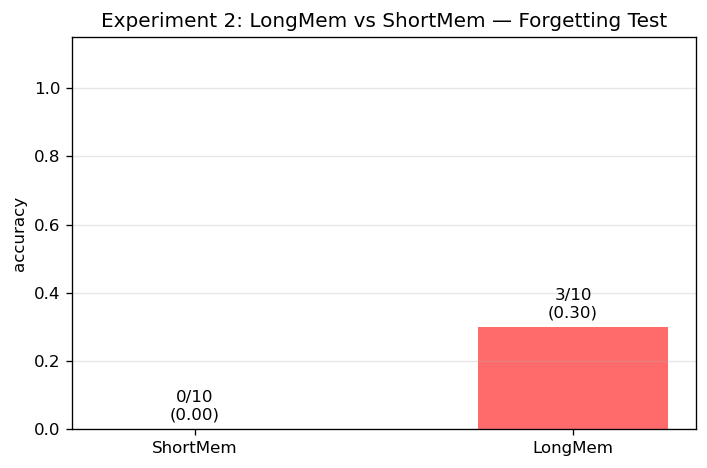

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
names = [r['strategy'] for r in exp2_results]
scores = [r['score'] for r in exp2_results]
bars = ax.bar(names, scores, color=['#4ECDC4', '#FF6B6B'], width=0.5)
for bar, r in zip(bars, exp2_results):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{r["passed"]}/{r["total"]}\n({r["score"]:.2f})',
            ha='center', va='bottom', fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('accuracy')
ax.set_title('Experiment 2: LongMem vs ShortMem — Forgetting Test')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULT_DIR / 'exp2_longmem_vs_shortmem_forgetting.png', dpi=150)
plt.show()

---
## 实验 3：不同向量库与嵌入方式的准确率对比

固定使用 LongMem 策略，对比：
1. ChromaDB（默认）
2. HNSW + BGE-M3（`BAAI/bge-m3`）
3. HNSW + bge-large-zh（`BAAI/bge-large-zh-v1.5`）
4. HNSW + sentence-transformers（`all-MiniLM-L6-v2`）

测试文件：`conversation_tests_forgetting.json`

In [7]:
BACKENDS = [
    {'name': 'ChromaDB', 'env': {'LONG_MEM_BACKEND': 'chromadb'}},
    {'name': 'HNSW+BGE-M3', 'env': {'LONG_MEM_BACKEND': 'hnsw', 'HNSW_EMBEDDING': 'bge-m3', 'HNSW_EMBEDDING_DEVICE': 'cuda'}},
    {'name': 'HNSW+bge-large-zh', 'env': {'LONG_MEM_BACKEND': 'hnsw', 'HNSW_EMBEDDING': 'bge-large-zh', 'HNSW_EMBEDDING_DEVICE': 'cuda'}},
    {'name': 'HNSW+sentence-transformers', 'env': {'LONG_MEM_BACKEND': 'hnsw', 'HNSW_EMBEDDING': 'sentence-transformers', 'HNSW_EMBEDDING_DEVICE': 'cuda'}},
]

exp3_configs = [
    {
        'tag': f'exp3_{b["name"]}',
        'strategies': 'LongMem',
        'test_file': 'conversation_tests_forgetting.json',
        'env': b['env'],
    }
    for b in BACKENDS
]

exp3_summaries = run_batch(exp3_configs)
exp3_results = []
for b, summary in zip(BACKENDS, exp3_summaries):
    p, t = extract_passed_total(summary)
    exp3_results.append({
        'name': b['name'],
        'score': extract_score(summary),
        'passed': p,
        'total': t,
    })

[缓存] 加载 exp3_ChromaDB.json
[缓存] 加载 exp3_HNSW+BGE-M3.json
[缓存] 加载 exp3_HNSW+bge-large-zh.json
[缓存] 加载 exp3_HNSW+sentence-transformers.json


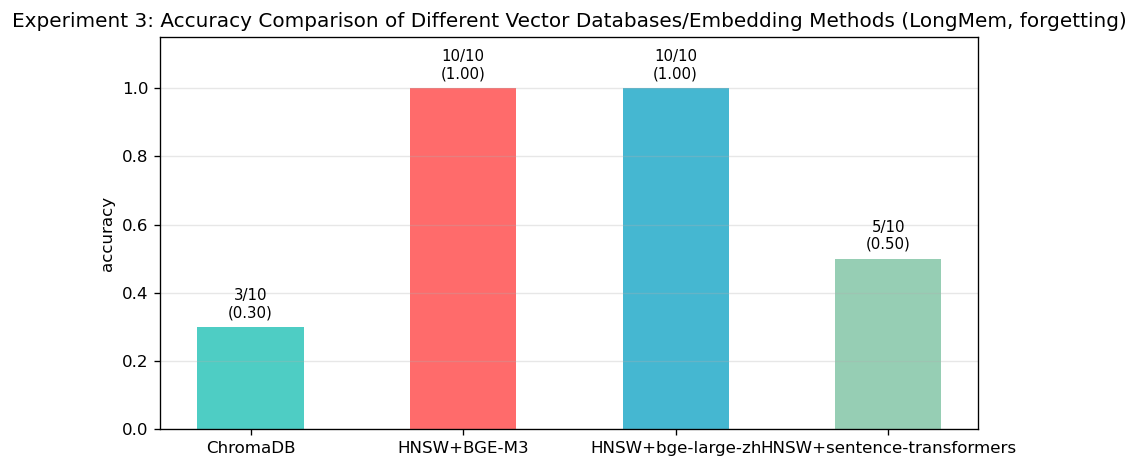

  ChromaDB                       score=0.3000  (3/10)
  HNSW+BGE-M3                    score=1.0000  (10/10)
  HNSW+bge-large-zh              score=1.0000  (10/10)
  HNSW+sentence-transformers     score=0.5000  (5/10)


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
names = [r['name'] for r in exp3_results]
scores = [r['score'] for r in exp3_results]
colors = ['#4ECDC4', '#FF6B6B', '#45B7D1', '#96CEB4']
bars = ax.bar(names, scores, color=colors, width=0.5)
for bar, r in zip(bars, exp3_results):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{r["passed"]}/{r["total"]}\n({r["score"]:.2f})',
            ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel('accuracy')
ax.set_title('Experiment 3: Accuracy Comparison of Different Vector Databases/Embedding Methods (LongMem, forgetting)')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULT_DIR / 'exp3_backend_comparison.png', dpi=150)
plt.show()
print('\n'.join([f'  {r["name"]:30s} score={r["score"]:.4f}  ({r["passed"]}/{r["total"]})' for r in exp3_results]))

---
## 实验 5：BGE-M3 混合检索 (Dense+Sparse) vs 纯 Dense — 高难度遗忘测试

使用 **高难度遗忘测试集** (`conversation_tests_forgetting_hard.json`)，包含：
- **语义混淆**：相似人名/颜色/地点/公司名，需要精确关键词匹配
- **信息更新**：先告诉一个值，后续又变更，需要记住最新值
- **长距离精确召回**：大量语义相关干扰词后回忆精确字符串
- **交叉引用推理**：需要记住多条信息并交叉关联

对比 BGE-M3 在两种检索模式下的表现：
1. **Dense-Only**：仅使用稠密向量检索
2. **Hybrid-0.7-0.3**：Dense (0.7) + Sparse (0.3) RRF 融合
3. **Hybrid-0.5-0.5**：Dense (0.5) + Sparse (0.5) 均等融合
4. **Hybrid-0.3-0.7**：Dense (0.3) + Sparse (0.7) 偏稀疏

测试文件：`conversation_tests_forgetting_hard.json` (60 题评估)

In [5]:
HYBRID_CONFIGS = [
    {'name': 'Dense-Only', 'env': {'LONG_MEM_BACKEND': 'hnsw', 'HNSW_EMBEDDING': 'bge-m3', 'HNSW_EMBEDDING_DEVICE': 'cuda'}},
    {'name': 'Hybrid-0.7-0.3', 'env': {'LONG_MEM_BACKEND': 'hnsw', 'HNSW_EMBEDDING': 'bge-m3', 'HNSW_EMBEDDING_DEVICE': 'cuda',
                                         'LONG_MEM_HYBRID': 'true', 'LONG_MEM_HYBRID_DENSE_WEIGHT': '0.7', 'LONG_MEM_HYBRID_SPARSE_WEIGHT': '0.3'}},
    {'name': 'Hybrid-0.5-0.5', 'env': {'LONG_MEM_BACKEND': 'hnsw', 'HNSW_EMBEDDING': 'bge-m3', 'HNSW_EMBEDDING_DEVICE': 'cuda',
                                         'LONG_MEM_HYBRID': 'true', 'LONG_MEM_HYBRID_DENSE_WEIGHT': '0.5', 'LONG_MEM_HYBRID_SPARSE_WEIGHT': '0.5'}},
    {'name': 'Hybrid-0.3-0.7', 'env': {'LONG_MEM_BACKEND': 'hnsw', 'HNSW_EMBEDDING': 'bge-m3', 'HNSW_EMBEDDING_DEVICE': 'cuda',
                                         'LONG_MEM_HYBRID': 'true', 'LONG_MEM_HYBRID_DENSE_WEIGHT': '0.3', 'LONG_MEM_HYBRID_SPARSE_WEIGHT': '0.7'}},
]

exp5_configs = [
    {
        'tag': f'exp5_{c["name"]}',
        'strategies': 'LongMem',
        'test_file': 'conversation_tests_forgetting_hard.json',
        'env': c['env'],
    }
    for c in HYBRID_CONFIGS
]

exp5_summaries = run_batch(exp5_configs)
exp5_results = []
for c, summary in zip(HYBRID_CONFIGS, exp5_summaries):
    p, t = extract_passed_total(summary)
    exp5_results.append({
        'name': c['name'],
        'score': extract_score(summary),
        'passed': p,
        'total': t,
    })

[缓存] 加载 exp5_Hybrid-0.7-0.3.json
[运行] exp5_Dense-Only
[缓存] 加载 exp5_Hybrid-0.5-0.5.json
[运行] exp5_Hybrid-0.3-0.7
[完成] exp5_Dense-Only | RC=0 | 290.2s
[完成] exp5_Hybrid-0.3-0.7 | RC=0 | 296.3s


/tmp/ipykernel_4402/3527385870.py:14: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4402/3527385870.py:15: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from current font.
  plt.savefig(RESULT_DIR / 'exp5_hybrid_vs_dense_forgetting.png', dpi=150)


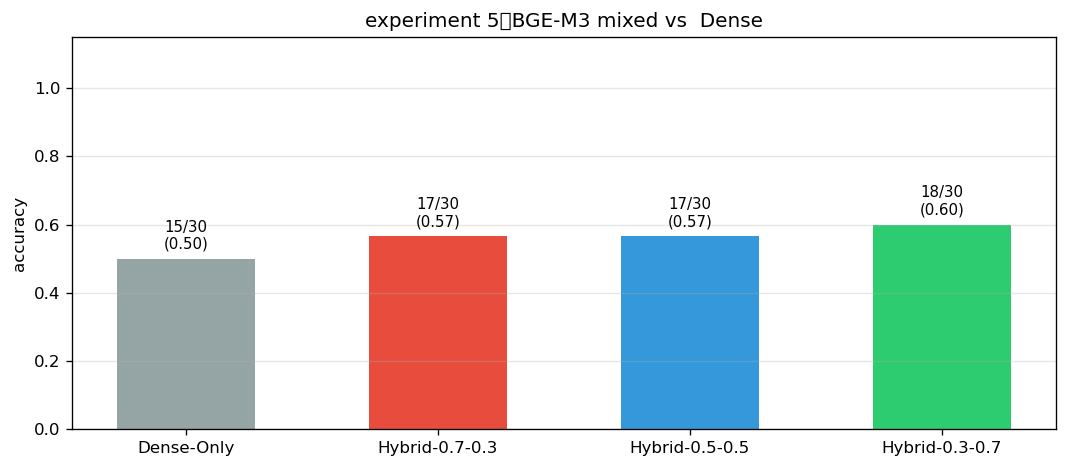

  Dense-Only            15/30 = 0.5000
  Hybrid-0.7-0.3        17/30 = 0.5667
  Hybrid-0.5-0.5        17/30 = 0.5667
  Hybrid-0.3-0.7        18/30 = 0.6000


In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
names = [r['name'] for r in exp5_results]
scores = [r['score'] for r in exp5_results]
colors = ['#95a5a6', '#e74c3c', '#3498db', '#2ecc71']
bars = ax.bar(names, scores, color=colors, width=0.55)
for bar, r in zip(bars, exp5_results):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{r["passed"]}/{r["total"]}\n({r["score"]:.2f})',
            ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel('accuracy')
ax.set_title('experiment 5：BGE-M3 mixed vs  Dense')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULT_DIR / 'exp5_hybrid_vs_dense_forgetting.png', dpi=150)
plt.show()
print('\n'.join([f'  {r["name"]:20s}  {r["passed"]:2d}/{r["total"]:2d} = {r["score"]:.4f}' for r in exp5_results]))

### 实验 5：逐条详细结果

展示每个测试组的通过/总数，以便看到混合检索在不同遗忘场景下的细微差异。

In [ ]:
HYBRID_CONFIGS = [
    {'name': 'Dense-Only', 'env': {'LONG_MEM_BACKEND': 'hnsw', 'HNSW_EMBEDDING': 'bge-m3', 'HNSW_EMBEDDING_DEVICE': 'cuda'}},
    {'name': 'Hybrid-0.7-0.3', 'env': {'LONG_MEM_BACKEND': 'hnsw', 'HNSW_EMBEDDING': 'bge-m3', 'HNSW_EMBEDDING_DEVICE': 'cuda',
                                         'LONG_MEM_HYBRID': 'true', 'LONG_MEM_HYBRID_DENSE_WEIGHT': '0.7', 'LONG_MEM_HYBRID_SPARSE_WEIGHT': '0.3'}},
    {'name': 'Hybrid-0.5-0.5', 'env': {'LONG_MEM_BACKEND': 'hnsw', 'HNSW_EMBEDDING': 'bge-m3', 'HNSW_EMBEDDING_DEVICE': 'cuda',
                                         'LONG_MEM_HYBRID': 'true', 'LONG_MEM_HYBRID_DENSE_WEIGHT': '0.5', 'LONG_MEM_HYBRID_SPARSE_WEIGHT': '0.5'}},
    {'name': 'Hybrid-0.3-0.7', 'env': {'LONG_MEM_BACKEND': 'hnsw', 'HNSW_EMBEDDING': 'bge-m3', 'HNSW_EMBEDDING_DEVICE': 'cuda',
                                         'LONG_MEM_HYBRID': 'true', 'LONG_MEM_HYBRID_DENSE_WEIGHT': '0.3', 'LONG_MEM_HYBRID_SPARSE_WEIGHT': '0.7'}},
]

exp5_configs = [
    {
        'tag': f'exp5_{c["name"]}',
        'strategies': 'LongMem',
        'test_file': 'conversation_tests_forgetting_hard.json',
        'env': c['env'],
    }
    for c in HYBRID_CONFIGS
]

exp5_summaries = run_batch(exp5_configs)
exp5_results = []
for c, summary in zip(HYBRID_CONFIGS, exp5_summaries):
    p, t = extract_passed_total(summary)
    exp5_results.append({
        'name': c['name'],
        'score': extract_score(summary),
        'passed': p,
        'total': t,
    })

---
## 实验 6：Anti-Pollution 过滤效果 - 污染测试

使用污染测试集 (`conversation_tests_pollution.json`)，测试 anti-pollution 机制的效果。

测试集包含 10 条初始信息 + 10 条后续更新（覆盖全部初始信息），
中间穿插大量干扰和陷阱问题（提及旧值来混淆）。

评估分三类各 10 题：
- **更新值回忆**：必须回答最新值（如住址现在是海淀区，不是朝阳区）
- **陷阱判断**：旧值是否还有效
- **变更追踪**：说出旧值和新值

对比条件：
1. Anti-Pollution 关闭 (ANTI_POLLUTION=false)
2. Anti-Pollution 开启 (ANTI_POLLUTION=true)

均使用 HNSW + BGE-M3 Hybrid (0.5/0.5)。

In [9]:
POLLUTION_CONFIGS = [
    {
        'name': 'AntiPollution-OFF',
        'env': {
            'LONG_MEM_BACKEND': 'hnsw',
            'HNSW_EMBEDDING': 'bge-m3',
            'HNSW_EMBEDDING_DEVICE': 'cuda',
            'LONG_MEM_HYBRID': 'true',
            'LONG_MEM_HYBRID_DENSE_WEIGHT': '0.5',
            'LONG_MEM_HYBRID_SPARSE_WEIGHT': '0.5',
            'LONG_MEM_ANTI_POLLUTION': 'false',
        },
    },
    {
        'name': 'AntiPollution-ON',
        'env': {
            'LONG_MEM_BACKEND': 'hnsw',
            'HNSW_EMBEDDING': 'bge-m3',
            'HNSW_EMBEDDING_DEVICE': 'cuda',
            'LONG_MEM_HYBRID': 'true',
            'LONG_MEM_HYBRID_DENSE_WEIGHT': '0.5',
            'LONG_MEM_HYBRID_SPARSE_WEIGHT': '0.5',
            'LONG_MEM_ANTI_POLLUTION': 'true',
        },
    },
]

exp6_configs = [
    {
        'tag': f'exp6_{c["name"]}',
        'strategies': 'LongMem',
        'test_file': 'conversation_tests_pollution.json',
        'env': c['env'],
    }
    for c in POLLUTION_CONFIGS
]

exp6_summaries = run_batch(exp6_configs)
exp6_results = []
for c, summary in zip(POLLUTION_CONFIGS, exp6_summaries):
    p, t = extract_passed_total(summary)
    exp6_results.append({
        'name': c['name'],
        'score': extract_score(summary),
        'passed': p,
        'total': t,
    })



[运行] exp6_AntiPollution-ON
[缓存] 加载 exp6_AntiPollution-OFF.json
[完成] exp6_AntiPollution-ON | RC=0 | 295.9s


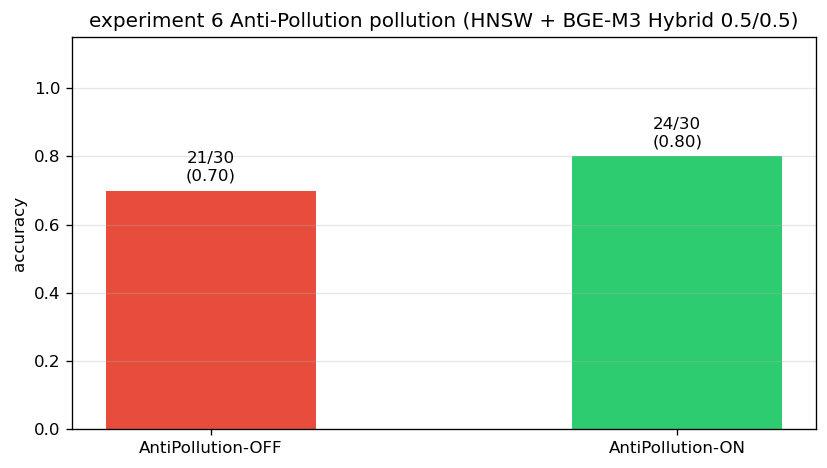

  AntiPollution-OFF          21/30 = 0.7000
  AntiPollution-ON           24/30 = 0.8000


In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
names = [r['name'] for r in exp6_results]
scores = [r['score'] for r in exp6_results]
colors = ['#e74c3c', '#2ecc71']
bars = ax.bar(names, scores, color=colors, width=0.45)
for bar, r in zip(bars, exp6_results):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{r["passed"]}/{r["total"]}\n({r["score"]:.2f})',
            ha='center', va='bottom', fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('accuracy')
ax.set_title('experiment 6 Anti-Pollution pollution (HNSW + BGE-M3 Hybrid 0.5/0.5)')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULT_DIR / 'exp6_anti_pollution.png', dpi=150)
plt.show()
print('\n'.join([f'  {r["name"]:25s}  {r["passed"]:2d}/{r["total"]:2d} = {r["score"]:.4f}' for r in exp6_results]))

### \u5b9e\u9a8c 6\uff1a\u5206\u9898\u578b\u7ec6\u9879\u7ed3\u679c

\u6309\u4e09\u7c7b\u8bc4\u4f30\u9898\u578b\u62c6\u5206\u7ed3\u679c\uff1a\u66f4\u65b0\u503c\u56de\u5fc6\uff08Q1-Q10\uff09\u3001\u9677\u9631\u5224\u65ad\uff08Q11-Q20\uff09\u3001\u53d8\u66f4\u8ffd\u8e2a\uff08Q21-Q30\uff09\u3002

In [ ]:
print('=' * 70)
print('\u5b9e\u9a8c 6\uff1aAnti-Pollution \u8fc7\u6ee4\u6548\u679c \u2014 \u9010\u6761\u7ed3\u679c')
print('=' * 70)
for c, summary in zip(POLLUTION_CONFIGS, exp6_summaries):
    print(f'\n--- {c["name"]} ---')
    for rec in summary.get('records', []):
        print(f'  [{rec["test_id"]}] {rec["passed"]}/{rec["total"]} score={rec["score"]:.4f}')
    p, t = extract_passed_total(summary)
    print(f'  \u603b\u8ba1: {p}/{t} = {extract_score(summary):.4f}')



---
## 汇总对比表

In [ ]:
print('=' * 70)
print('实验汇总')
print('=' * 70)
print()
print('--- 实验 1：上下文窗口 vs 一致性 ---')
for r in exp1_results:
    print(f'  window={r["window"]:5d}  {r["passed"]:2d}/{r["total"]:1d} = {r["score"]:.4f}')
print()
print('--- 实验 2：LongMem vs ShortMem (遗忘测试) ---')
for r in exp2_results:
    print(f'  {r["strategy"]:20s}  {r["passed"]:2d}/{r["total"]:2d} = {r["score"]:.4f}')
print()
print('--- 实验 3：向量库/嵌入方式对比 ---')
for r in exp3_results:
    print(f'  {r["name"]:30s}  {r["passed"]:2d}/{r["total"]:2d} = {r["score"]:.4f}')
print()
print('--- 实验 5：混合检索 vs 纯 Dense (高难度遗忘) ---')
for r in exp5_results:
    print(f'  {r["name"]:20s}  {r["passed"]:2d}/{r["total"]:2d} = {r["score"]:.4f}')
print()
print('--- 实验 6：Anti-Pollution 过滤效果 ---')
for r in exp6_results:
    print(f'  {r["name"]:25s}  {r["passed"]:2d}/{r["total"]:2d} = {r["score"]:.4f}')
print()
